# Recap about the fundamentals of Deep Learning

📆 What's on the agenda for this recap?

- ***Intro***: How to read the docs
- ***Part 1️⃣***: Tensorflow and Keras de-mystified (👨🏻‍🏫 Teacher-led)
- ***Part 2️⃣***: Tensorflow vs Numpy? (👨🏻‍🏫 Teacher-led)
- ***Part 3️⃣***: Forest Fires Challenge (👩‍🎓 Student-led)

## Intro: How to read the docs?

✅ [Keras.io](https://keras.io/getting_started/) is the documentation of the high-level Keras API:
- It has plenty of tutorials for many Deep Learning tasks
- It includes more detailed developer guides too
- As well as the complete Keras API documentation
- Make sure you check the Keras 3 documentation at all times

&nbsp;

✅ [Tensorflow.org](https://www.tensorflow.org/overview) provides you with two main pages to refer to:
- [Tutorial](https://www.tensorflow.org/tutorials)
- [Guide](https://www.tensorflow.org/guide)
- You can even run `Colab-Notebooks` of these tutorials

&nbsp;

✅ TensorFlow [API docs](https://www.tensorflow.org/api_docs/python/tf/) is the documentation of the extensive (and sometimes very low-level) TensorFlow backed we use for Keras:
- It pops up in Google Search in priority
- [Sometimes](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential), it can give you references to related Tutorials or Guides

# 1️⃣ - Tensorflow and Keras demystified 
_(🧑🏻‍🏫 Teacher-led)_

👉 Goal: Using Tensorflow and Keras, create a dummy dataset and fit a dummy model with it

### (1) Tensors?

📚 [Online Guide](https://www.tensorflow.org/guide/tensor)

In [28]:
# It's OK to import everything for notebook based experimentation!
import tensorflow as tf
import keras
import numpy as np

In [29]:
# Tensors are wrappers around numpy objects

X = tf.constant([[1., 1., 1.],
                 [1., 1., 1.],
                 [1., 1., 1.]])
X

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [30]:
tf.ones((3,3))

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [31]:
x = X.numpy()
x

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)

In [32]:
# Tensors have a shape
X.shape

TensorShape([3, 3])

In [33]:
# Tensors can be initialized from Numpy objects
tf.constant(x)

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [34]:
# They can be manipulated with syntax that is similar to Numpy
tf.add(X,X)

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[2., 2., 2.],
       [2., 2., 2.],
       [2., 2., 2.]], dtype=float32)>

In [35]:
# Conversely, Numpy also accept Tensor elements!
np.add(X,X)

array([[2., 2., 2.],
       [2., 2., 2.],
       [2., 2., 2.]], dtype=float32)

In [36]:
# Example of a custom MSE loss function using Tensors

def loss(y_true, y_pred):
    err = y_true - y_pred
    return tf.reduce_mean(tf.square(err))

y_true = tf.ones((10,3))
y_pred = tf.ones((10,3)) + 0.1 * tf.random.normal((10,3))

loss(y_true, y_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=0.006481863>

#### Other Tensors?

**Sparse Tensors**
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/sparse_tensors.png">

In [37]:
sparse_tensor = tf.sparse.SparseTensor(indices=[[0, 0], [1, 2]],
                                       values=[1, 2],
                                       dense_shape=[3, 4])
sparse_tensor.shape

TensorShape([3, 4])

**Ragged Tensors**
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/ragged_tensors.png">

In [38]:
ragged_list = [
    [0, 1, 2, 3],
    [4, 5],
    [6, 7, 8],
    [9]]

ragged_tensor = tf.ragged.constant(ragged_list)
ragged_tensor.shape

TensorShape([4, None])

### (2) Build a neural network with `Sequential API`

👉 Let's generate 10 random observations `X` of 3 features each, and a unidimensional target `y` 

In [39]:
# Let's generate 100 observations of with 10 features for each of them
X = tf.random.uniform((100,10))

In [40]:
# And create our dummy target as simply the mean of each observation
y = tf.reduce_mean(X, axis=1)
y.shape

TensorShape([100])

👉 Let's build a simple dense model that "works"

In [41]:
from keras import Sequential, Input, layers

In [42]:
# Usual syntax

model = Sequential()
model.add(Input(shape=(10,)))
model.add(layers.Dense(30, activation='relu'))
model.add(layers.Dense(1))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Equivalent
model = Sequential([
    Input(shape=(10,)),
    layers.Dense(30, activation='relu'),
    layers.Dense(1),
])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# What if we don't specify the Input layer?
model = Sequential()
model.add(layers.Dense(30, activation='relu'))
model.add(layers.Dense(1))

In [45]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
# One can still access all the layers individually
model.layers

[<Dense name=dense_14, built=False>, <Dense name=dense_15, built=False>]

In [47]:
# And call the layer with a "tensor" as input
x1 = model.layers[0](X)

# x1 is our activation from layer 1, with random (initial) weights
x1.shape

TensorShape([100, 30])

In [48]:
# x2 is our output
x2 = model.layers[1](x1)
x2.shape

TensorShape([100, 1])

### (3) Keras Input

Why do we use this?
```python
keras.Input(shape=(10,))
```
Instead of passing 100 **real** observations to your layers, simply pass a `keras.Input` of `None` observations of similar shape (10,).  

It is used for computation optimization purposes (memory pre-allocation and network graphs for parallelization) 

In [49]:
inputs = keras.Input(shape=(10,))
inputs

<KerasTensor shape=(None, 10), dtype=float32, sparse=False, name=keras_tensor_21>

In [50]:
model.layers[0](inputs)

<KerasTensor shape=(None, 30), dtype=float32, sparse=False, name=keras_tensor_22>

In [51]:
x = model.layers[0](inputs) # Input layer
x = layers.Dense(30, activation='relu')(inputs) # First layer output
x = layers.Dense(20, activation='relu')(x) # Second layer output
x = layers.Dense(10, activation='relu')(x) # Third layer output
outputs = layers.Dense(1)(x)               # Final layer output

outputs.shape

(None, 1)

In [52]:
# Keras allows you to build a model from an input and output layer
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,171 (4.57 KB)

 Trainable params: 1,171 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

☝️ This way of building models is called Keras [Functional API](https://www.tensorflow.org/guide/keras/functional)
- as opposed to [Sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential): `model.add(...)`
- It is mandatory for complex (non-sequential) architecture...
- Used everywhere in the docs

# 2️⃣ - Tensorflow vs. Numpy?

### Difference between an array and a tensor?

👉 The important differences between NumPy arrays and tf.Tensors are:

1. Tensors are immutable
2. Tensors can be backed by accelerator memory (like GPU, TPU)

**Immutable**

In [53]:
# an array element can be reassigned

array = np.array([1,1,1])

array[1] = 2

array

array([1, 2, 1])

In [55]:
# a tensor element can't be reassigned

tensor = tf.constant([1., 1., 1.])

# tensor[1] = 2

**Backed by accelerator memory**

Tensors are backed by accelerator memory (like GPU, TPU). You can manually select the processor on which to perform your tensor operations.

⏩⏩⏩ Check out the [documentation](https://www.tensorflow.org/guide/gpu).

In [56]:
# Check CPU's available
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))

Num CPUs Available:  1


In [57]:
# Check GPU's available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


It is unliklely that your computer will have a GPU... Guess who offers free GPU usage? Google! 

👉 **Let's switch to Google Colab to continue the recap and compare the processing times.**

In [58]:
# If you've set up Colab correctly, you should have a GPU avaiable.
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [59]:
# Matrix multiplication function performing operation and returning us the time.
import time

def time_matmul(types,x):

    start = time.time()

    if types=='numpy':
        np.matmul(x,x)

    else:
        tf.matmul(x,x)

    diff = time.time() - start

    return diff*1000


👇 Run this cell twice (the first time it runs, tensorflow compilation for GPU takes a bit of time)

In [62]:
shape_dim = []
num_time = []
cpu_tf_time = []
gpu_tf_time = []

for shape in range(500,2001,100):

    print(f"Multiplication of shape [{shape},{shape}]")

    # Start with shape 500,500 to 2000,2000 with an increase of 100
    shape_dim.append(shape)

    # Numpy multiplication
    x_np = np.random.uniform(size=[shape,shape])
    num_time.append(time_matmul('numpy',x_np))

    # Tensor in CPU
    with tf.device("CPU:0"):
        x = tf.random.uniform([shape, shape])
        cpu_tf_time.append(time_matmul('cpu',x))

    # Tensor in GPU multiplication
    with tf.device("GPU:0"): #Or GPU:1 for the 2nd GPU, GPU:2 for the 3rd etc.
        x = tf.random.uniform([shape, shape])
        gpu_tf_time.append(time_matmul('gpu',x))

print("Done multiplying!")

Multiplication of shape [500,500]
Multiplication of shape [600,600]
Multiplication of shape [700,700]
Multiplication of shape [800,800]
Multiplication of shape [900,900]
Multiplication of shape [1000,1000]
Multiplication of shape [1100,1100]
Multiplication of shape [1200,1200]
Multiplication of shape [1300,1300]
Multiplication of shape [1400,1400]
Multiplication of shape [1500,1500]
Multiplication of shape [1600,1600]
Multiplication of shape [1700,1700]
Multiplication of shape [1800,1800]
Multiplication of shape [1900,1900]
Multiplication of shape [2000,2000]
Done multiplying!


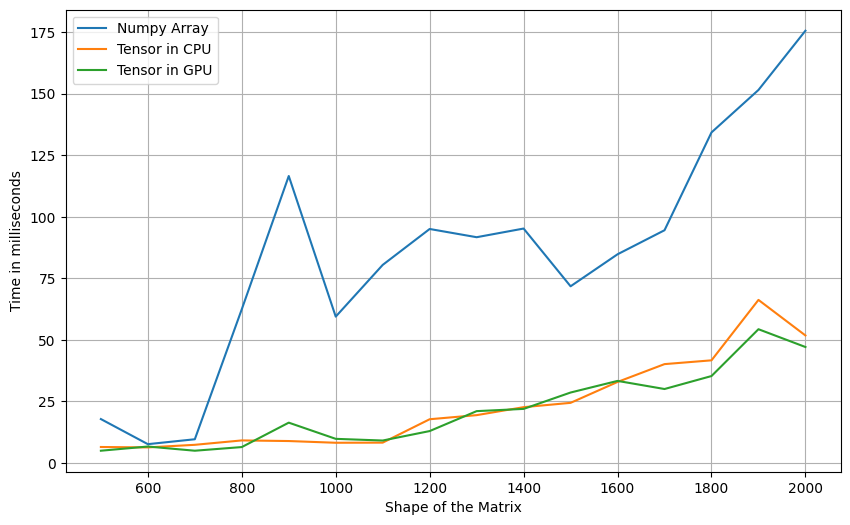

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(shape_dim, num_time, label="Numpy Array")
plt.plot(shape_dim, cpu_tf_time, label="Tensor in CPU")
plt.plot(shape_dim, gpu_tf_time, label="Tensor in GPU")
plt.grid()
plt.xlabel("Shape of the Matrix")
plt.ylabel("Time in milliseconds")
plt.legend()

👉 **Check out our [tutorial](https://kitt.lewagon.com/knowledge/tutorials/data_google_colab) on how to set up Google Colab, you'll be using it in the coming days**

# 3️⃣ (optional) - Forest Fires Challenge 
(👩‍🎓Student-led)

### (1) Data

`tensorflow_dataset` provides many `Datasets` that can be found <a href="https://www.tensorflow.org/datasets/catalog/overview">here</a>

Let's load the **`forest_fires`** dataset. The target is area damaged by fire (more details here https://www.tensorflow.org/datasets/catalog/forest_fires).

In [64]:
import tensorflow_datasets as tfds
import pandas as pd
from sklearn.model_selection import train_test_split

In [65]:
area, features = tfds.as_numpy(tfds.load(
    'forest_fires',
    split='train',
    batch_size=-1,
    as_supervised=True,
))

2025-05-04 17:41:22.381629: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/517 [00:00<?, ? examples/s]

Shuffling /Users/davywai/tensorflow_datasets/forest_fires/incomplete.RXMSQ2_0.0.1/forest_fires-train.tfrecord*…

Dataset forest_fires downloaded and prepared to /Users/davywai/tensorflow_datasets/forest_fires/0.0.1. Subsequent calls will reuse this data.


In [66]:
X = pd.DataFrame(features).values
y = area
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y = area

### (2) Declare the general architecture of your model



❓ Import Keras and declare a Sequential model

In [67]:
from tensorflow.keras import models

model = models.Sequential()

❓ Add a Dense layer with 50 neurons and the `relu` activation function. Do not forget to specify the input shape.

In [68]:
from tensorflow.keras import layers

model.add(Input(shape=(12,)))
model.add(layers.Dense(50, activation="relu"))

❓ Add a second fully connected layer, with 20 neurons and the `relu` activation function.

In [69]:
model.add(layers.Dense(20, activation="relu"))

❓ Add a last layer that suits your regression task

In [70]:
model.add(layers.Dense(1, activation="linear"))

❓ Check the number of parameters of your model.

Re-count them manually to make sure you understood the numbers of parameters involved in each layer of your Dense Neural Network

In [71]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 50)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,691 (6.61 KB)

 Trainable params: 1,691 (6.61 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
(12*50 + 50) + (50*20 + 20) + (20*1 + 1)

1691

### (3) Define how your model is trained
 


❓ Compile the model with the `adam` `optimizer` and the `mse` `loss`

In [73]:
model.compile(optimizer='adam',
              loss='mse')

❓Run the model on this random data; don't forget to select a number of `epochs` and a `batch_size`. Store the returned result in `history`.

In [74]:
history = model.fit(X_train, y_train,
                    batch_size=16,
                    epochs=2000,
                    verbose=0)

❓ Plot the model convergence

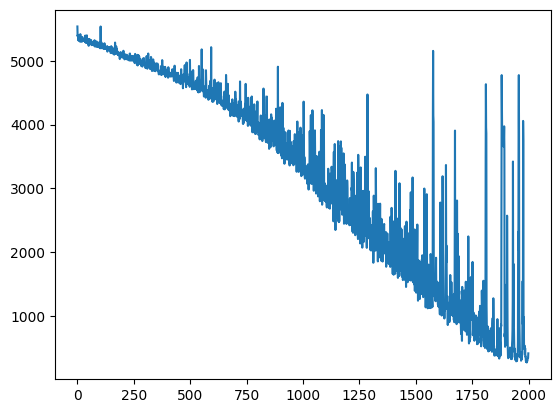

In [75]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.show()

❓ Write an entire model with its compilation within an `init_model` function

In [76]:
def init_model():

    model = models.Sequential()
    model.add(layers.Dense(20, activation='relu'))
    model.add(layers.Dense(10, activation='relu'))
    model.add(layers.Dense(1, activation='linear'))

    model.compile(optimizer='adam',
              loss='mse')

    return model

You are advised to systematically rebuild a model (with an init function) before fitting some data in order to re-initialize the model's parameters.

The model you just wrote is suited for regression tasks.

What if we want to perform a binary classification task?

❓ Write another `init_model_2` function in which you will change:
* the last layer of the architecture 
* and the compilation method

used in a binary class classification problem.

In [77]:
def init_model_2():

    model = models.Sequential()
    model.add(layers.Dense(20, activation='relu'))
    model.add(layers.Dense(10, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
              loss='binary_crossentropy')

    return model

❓ Write a last function to define a model for a classification problem with 10 classes.

In [78]:
def init_model_3():

    model = models.Sequential()
    model.add(layers.Dense(20, activation='relu'))
    model.add(layers.Dense(10, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy')

    return model